In [1]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as nps
iris = load_iris()
df_iris = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target
print("✅ Step 1 Complete: Iris Dataset Loaded!")
df_iris.head()

✅ Step 1 Complete: Iris Dataset Loaded!


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [2]:
species_counts = df_iris['target'].value_counts()
print("Species Distribution (0: Setosa, 1: Versicolor, 2: Virginica):")
print(species_counts)
print("\nMissing Values:")
print(df_iris.isnull().sum())

Species Distribution (0: Setosa, 1: Versicolor, 2: Virginica):
target
0    50
1    50
2    50
Name: count, dtype: int64

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


📊 Generating Species Correlation Plot...


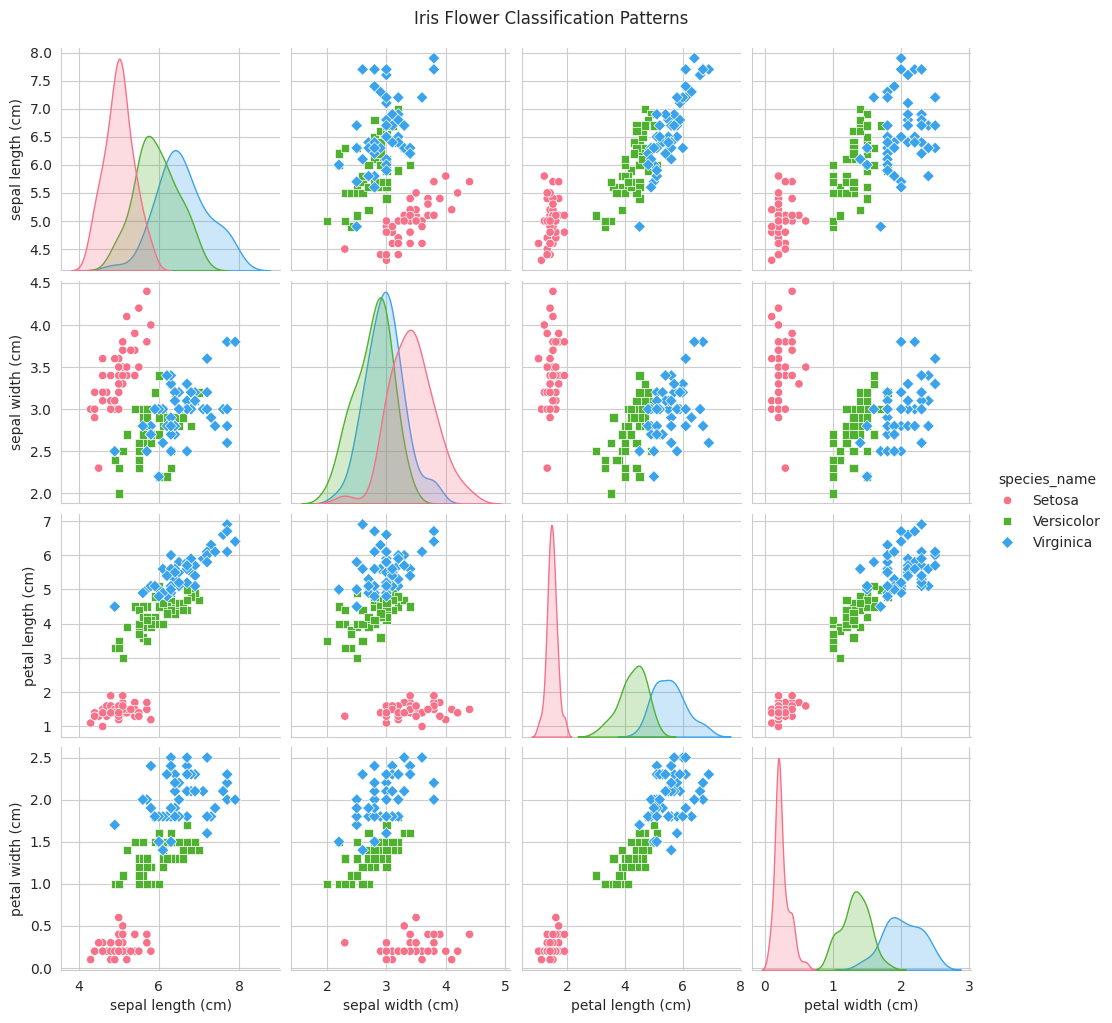

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")
df_viz = df_iris.copy()
df_viz['species_name'] = df_viz['target'].replace({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})
print("📊 Generating Species Correlation Plot...")
sns.pairplot(df_viz.drop('target', axis=1), hue='species_name', palette='husl', markers=["o", "s", "D"])
plt.suptitle("Iris Flower Classification Patterns", y=1.02)
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
X = df_iris.drop(['target'], axis=1)
y = df_iris['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("✅ Step 4 Complete: Data Splitting Done!")
print(f"Total Samples: {len(df_iris)}")
print(f"Training set: {len(X_train)} samples")
print(f"Testing set: {len(X_test)} samples")

✅ Step 4 Complete: Data Splitting Done!
Total Samples: 150
Training set: 120 samples
Testing set: 30 samples


In [5]:
from sklearn.ensemble import RandomForestClassifier
from tqdm.notebook import tqdm
import time
print("🚀 Initializing Iris Classification Model (Random Forest)...")
pbar = tqdm(total=100, desc="Training Progress", bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt}')
iris_model = RandomForestClassifier(n_estimators=100, random_state=42)
for i in range(10):
    time.sleep(0.1)
    pbar.update(10)
iris_model.fit(X_train, y_train)
pbar.close()
print("\n✅ Training Complete! Model is now ready to classify flowers.")

🚀 Initializing Iris Classification Model (Random Forest)...


Training Progress:   0%|          | 0/100


✅ Training Complete! Model is now ready to classify flowers.


🎯 Model Accuracy Report:
--------------------------
Overall Accuracy: 100.00%

Detailed Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



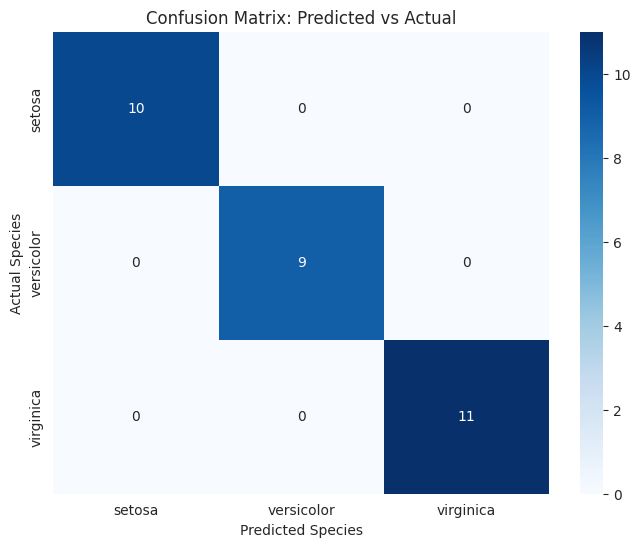

In [6]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = iris_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Model Accuracy Report:")
print(f"--------------------------")
print(f"Overall Accuracy: {accuracy*100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("Confusion Matrix: Predicted vs Actual")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.show()

In [7]:
print("--- 🌸 Iris Flower Species Predictor ---")
sepal_len = float(input("Enter Sepal Length (cm): "))
sepal_wid = float(input("Enter Sepal Width (cm): "))
petal_len = float(input("Enter Petal Length (cm): "))
petal_wid = float(input("Enter Petal Width (cm): "))
user_input = np.array([[sepal_len, sepal_wid, petal_len, petal_wid]])
prediction = iris_model.predict(user_input)
predicted_species = iris.target_names[prediction[0]]
print(f"\n--- 📋 Classification Result ---")
print(f"Based on the measurements, this flower is: **{predicted_species.upper()}**")
if predicted_species == 'setosa':
    print("Note: Setosa flowers typically have very small petals compared to other species.")

--- 🌸 Iris Flower Species Predictor ---
Enter Sepal Length (cm): 20
Enter Sepal Width (cm): 10
Enter Petal Length (cm): 20
Enter Petal Width (cm): 10

--- 📋 Classification Result ---
Based on the measurements, this flower is: **VIRGINICA**


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
